# 03 — Event Study : réaction des marchés aux décisions BCE

**Projet** : Transmission de la politique monétaire de la BCE  
**Auteur** : ISLEYEN Volkan  
**Date** : Mai 2026

## Objectif

Mesurer la réaction des marchés financiers européens autour des décisions de 
politique monétaire de la BCE, en isolant l'effet propre de l'annonce du bruit 
de marché ambiant.

## Méthodologie

Event study classique :

1. **Fenêtre d'estimation** : [-30, -6] jours avant chaque décision — sert à 
   estimer le rendement "normal" attendu
2. **Fenêtre d'événement** : [-5, +5] jours autour de la décision — sert à 
   mesurer la réaction effective
3. **Rendement anormal (AR)** : écart entre rendement observé et rendement normal
4. **Rendement anormal cumulé (CAR)** : somme des AR sur la fenêtre d'événement

## Variables étudiées

- Rendements de l'EURO STOXX 50
- Variation de la volatilité (VSTOXX)
- Variation des spreads souverains (Italie en particulier)

## Données en entrée

- `data/processed/data_clean.csv` — données de marché nettoyées
- `data/processed/bce_events.csv` — dates et amplitudes des décisions BCE

In [1]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Détection automatique de la racine du projet
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "output" / "figures"
TABLES = PROJECT_ROOT / "output" / "tables"

# Créer les dossiers de sortie si besoin
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

print("Librairies importées")
print(f"Données : {DATA_PROCESSED}")

Librairies importées
Données : C:\Users\volka\Documents\ecb-monetary-policy-transmission\data\processed


In [2]:
# Chargement des données nettoyées
print("Chargement des données...\n")

# DataFrame principal
df = pd.read_csv(DATA_PROCESSED / "data_clean.csv", index_col=0, parse_dates=True)

# Dates de décisions BCE
bce_events = pd.read_csv(DATA_PROCESSED / "bce_events.csv", index_col=0, parse_dates=True)

print(f"Données de marché : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nDécisions BCE : {len(bce_events)}")
print(bce_events)

Chargement des données...

Données de marché : 1509 lignes, 16 colonnes
Période : 2019-01-04 → 2024-12-30

Décisions BCE : 18
            Change_bp                         Description
Date                                                     
2019-09-12          0                   Hold (QE relancé)
2020-03-12          0                 Hold (PEPP annoncé)
2020-06-04          0                  Hold (PEPP étendu)
2021-12-16          0               Hold (PEPP recalibré)
2022-07-21         50     Hike +50 bp (fin taux négatifs)
2022-09-08         75                         Hike +75 bp
2022-10-27         75                         Hike +75 bp
2022-12-15         50                         Hike +50 bp
2023-02-02         50                         Hike +50 bp
2023-03-16         50                         Hike +50 bp
2023-05-04         25                         Hike +25 bp
2023-06-15         25                         Hike +25 bp
2023-07-27         25                         Hike +25 bp
2023

In [3]:
# Construction des fenêtres d'événement
# Pour chaque décision BCE, on extrait les jours autour de l'annonce

# Paramètres des fenêtres
ESTIMATION_START = -30   # début fenêtre d'estimation (jours avant l'événement)
ESTIMATION_END = -6      # fin fenêtre d'estimation
EVENT_START = -5         # début fenêtre d'événement
EVENT_END = +5           # fin fenêtre d'événement

def get_event_window(df, event_date, col="ret_sx5e"):
    """
    Pour une date d'événement donnée, retourne un DataFrame indexé par 
    le 'jour relatif' (-5, -4, ..., 0, ..., +5) avec la valeur de la variable.
    
    Le jour 0 = jour de l'annonce BCE (ou le jour de bourse le plus proche).
    """
    # Trouver la position de la date d'événement dans l'index
    # (ou la date de bourse la plus proche si l'annonce tombe un jour férié)
    idx_positions = df.index.get_indexer([event_date], method="nearest")
    event_pos = idx_positions[0]
    
    # Extraire la fenêtre complète [-30, +5]
    window_start = event_pos + ESTIMATION_START
    window_end = event_pos + EVENT_END
    
    # Sécurité : vérifier qu'on ne dépasse pas les bornes du DataFrame
    if window_start < 0 or window_end >= len(df):
        return None
    
    # Extraire la fenêtre
    window = df.iloc[window_start : window_end + 1].copy()
    
    # Ajouter la colonne "jour relatif"
    window["rel_day"] = range(ESTIMATION_START, EVENT_END + 1)
    
    return window[["rel_day", col]]

# Test sur la première décision (hausse de juillet 2022)
test_date = pd.Timestamp("2022-07-21")
test_window = get_event_window(df, test_date)

print(f"Test : fenêtre d'événement autour du {test_date.date()}")
print(f"Nombre de jours extraits : {len(test_window)}")
print(test_window)

Test : fenêtre d'événement autour du 2022-07-21
Nombre de jours extraits : 36
            rel_day  ret_sx5e
Date                         
2022-06-09      -30 -0.017164
2022-06-10      -29 -0.034208
2022-06-13      -28 -0.027235
2022-06-14      -27 -0.007831
2022-06-15      -26  0.016309
2022-06-16      -25 -0.030004
2022-06-17      -24  0.003073
2022-06-20      -23  0.009082
2022-06-21      -22  0.006942
2022-06-22      -21 -0.008439
2022-06-23      -20 -0.008216
2022-06-24      -19  0.027803
2022-06-27      -18  0.001615
2022-06-28      -17  0.002937
2022-06-29      -16 -0.009902
2022-06-30      -15 -0.017064
2022-07-01      -14 -0.001898
2022-07-04      -13  0.001191
2022-07-05      -12 -0.027185
2022-07-06      -11  0.018288
2022-07-07      -10  0.019293
2022-07-08       -9  0.005161
2022-07-11       -8 -0.009991
2022-07-12       -7  0.004415
2022-07-13       -6 -0.009532
2022-07-14       -5 -0.016746
2022-07-15       -4  0.023449
2022-07-18       -3  0.009918
2022-07-19       -2  0

In [4]:
# Calcul des rendements anormaux (AR) et cumulés (CAR) pour une décision

def compute_abnormal_returns(df, event_date, col="ret_sx5e"):
    """
    Pour une date d'événement :
    1. Estime le rendement "normal" = moyenne sur la fenêtre d'estimation [-30, -6]
    2. Calcule l'AR (Abnormal Return) = rendement observé - rendement normal
    3. Calcule le CAR (Cumulative AR) sur la fenêtre d'événement [-5, +5]
    
    Retourne un DataFrame indexé par jour relatif avec colonnes : valeur, AR, CAR
    """
    window = get_event_window(df, event_date, col)
    if window is None:
        return None
    
    # 1. Rendement normal : moyenne sur la fenêtre d'estimation
    estimation = window[(window["rel_day"] >= ESTIMATION_START) & 
                        (window["rel_day"] <= ESTIMATION_END)]
    normal_return = estimation[col].mean()
    
    # 2. On se restreint à la fenêtre d'événement [-5, +5]
    event = window[(window["rel_day"] >= EVENT_START) & 
                   (window["rel_day"] <= EVENT_END)].copy()
    
    # 3. Rendement anormal = observé - normal
    event["AR"] = event[col] - normal_return
    
    # 4. Rendement anormal cumulé
    event["CAR"] = event["AR"].cumsum()
    
    return event[["rel_day", col, "AR", "CAR"]]

# Test sur la décision de juillet 2022
test_ar = compute_abnormal_returns(df, pd.Timestamp("2022-07-21"))

print("Rendements anormaux — décision BCE du 2022-07-21 (+50 bp)\n")
print(test_ar.to_string(index=False))
print(f"\nCAR final (jour +5) : {test_ar['CAR'].iloc[-1]:.4f} ({test_ar['CAR'].iloc[-1]*100:.2f}%)")

Rendements anormaux — décision BCE du 2022-07-21 (+50 bp)

 rel_day  ret_sx5e        AR       CAR
      -5 -0.016746 -0.013044 -0.013044
      -4  0.023449  0.027152  0.014108
      -3  0.009918  0.013621  0.027729
      -2  0.021293  0.024995  0.052724
      -1 -0.000613  0.003089  0.055813
       0  0.003139  0.006841  0.062654
       1 -0.000006  0.003697  0.066351
       2  0.002130  0.005833  0.072183
       3 -0.008023 -0.004320  0.067863
       4  0.009027  0.012729  0.080592
       5  0.012237  0.015939  0.096532

CAR final (jour +5) : 0.0965 (9.65%)


In [5]:
# Calcul des AR et CAR pour TOUTES les décisions BCE

results = []           # pour stocker le CAR final de chaque décision
all_cars = {}          # pour stocker la trajectoire complète du CAR

for event_date, row in bce_events.iterrows():
    ar_df = compute_abnormal_returns(df, event_date)
    
    if ar_df is None:
        print(f"!!! {event_date.date()} : fenêtre incomplète, décision ignorée")
        continue
    
    car_final = ar_df["CAR"].iloc[-1]
    
    results.append({
        "date": event_date,
        "change_bp": row["Change_bp"],
        "type": "Hausse" if row["Change_bp"] > 0 else ("Baisse" if row["Change_bp"] < 0 else "Hold"),
        "CAR_final": car_final,
    })
    
    # Stocker la trajectoire complète (indexée par jour relatif)
    all_cars[event_date] = ar_df.set_index("rel_day")["CAR"]

# Transformer en DataFrame
results_df = pd.DataFrame(results).set_index("date")

print(f"Décisions analysées : {len(results_df)} / {len(bce_events)}\n")
print(results_df.to_string())

print(f"\n--- CAR moyen par type de décision ---")
print(results_df.groupby("type")["CAR_final"].agg(["mean", "std", "count"]).round(4))

Décisions analysées : 18 / 18

            change_bp    type  CAR_final
date                                    
2019-09-12          0    Hold   0.030609
2020-03-12          0    Hold  -0.293197
2020-06-04          0    Hold   0.030744
2021-12-16          0    Hold   0.015594
2022-07-21         50  Hausse   0.096532
2022-09-08         75  Hausse   0.014163
2022-10-27         75  Hausse   0.046569
2022-12-15         50  Hausse  -0.060098
2023-02-02         50  Hausse  -0.012968
2023-03-16         50  Hausse  -0.031315
2023-05-04         25  Hausse  -0.048302
2023-06-15         25  Hausse   0.009778
2023-07-27         25  Hausse  -0.005376
2023-09-14         25  Hausse   0.004007
2024-06-06        -25  Baisse  -0.009614
2024-09-12        -25  Baisse   0.018794
2024-10-17        -25  Baisse  -0.021533
2024-12-12        -25  Baisse  -0.011155

--- CAR moyen par type de décision ---
          mean     std  count
type                         
Baisse -0.0059  0.0173      4
Hausse  0.0013  0.0

### Commentaire des CAR par décision

Le calcule des rendements anormaux cumulés sur les 18 décisions fait ressortir plusieurs éléments dont certains appellent une discussion méthodologique. 

**Le "Hold" du 12 mars 2020 : un cas aberrant**
Cette décision affiche un CAR de -29%, sans rapport avec la politique monétaire. Le 12 mars 2020, la BCE n'a pas modifié ses taux, mais cette date est coïncide avec le krach lié au Covid-19. L'event study capture ici un choc éxogène massif, totalement étranger à l'évenement étudié. C'est une illustration directe de la principalelimite de la méthode : elle ne peut pas isoler la réaction à l'événement des autres chocs concomitants. 

**La question des décisions "Hold"**
Les quatre décisions sans changement de taux présentent un écart-type de CAR très élevé (0.16) comparé aux hausses (0.046) et aux baisses (0.017). Cette dispersion est presque entièrement due à mars 2020. Sur le plan méthodologique, l'inclusion des "holds" est par ailleurs discutable : un meeting sans changement de taux ne constitue pas un "événement" au sens strict de la méthode. Ces décisions seront donc traitée séparément de l'analyse principale. 

**Une dynamique temporelle dans les hausses**
Les dix hausses de taux ne réagissent pas de façon homogène. On observe un basculement net :

- Les premières hausses (juillet-octobre 2022) affichent des CAR **positifs**
- (+9.7 %, +1.4 %, +4.7 %).
- À partir de décembre 2022, les CAR deviennent majoritairement **négatifs** 
  (−6.0 %, −1.3 %, −3.1 %, −4.8 %).

Cette inversion suggère une interprétation économique : en début de cycle, le marché accueille favorablement le fait que la BCE réagisse à l'inflation (effet de "crédibilité retrouvée") ; à mesure que le resserrement se prolonge, c'est l'effet restrictif sur l'activité et les valorisations qui domine.

**CAR moyens par type — à interpréter avec prudence**  
Les moyennes brutes (Hausse : +0.13 %, Baisse : −0.59 %, Hold : −5.41 %) sont peu informatives en l'état : elles agrègent des effets de signe opposé pour les hausses, et sont polluées par les outliers (donnée abérante) pour les holds. L'analyse des trajectoires complètes de CAR (graphique suivant) et les tests de significativité permettront d'aller au-delà de ces moyennes.

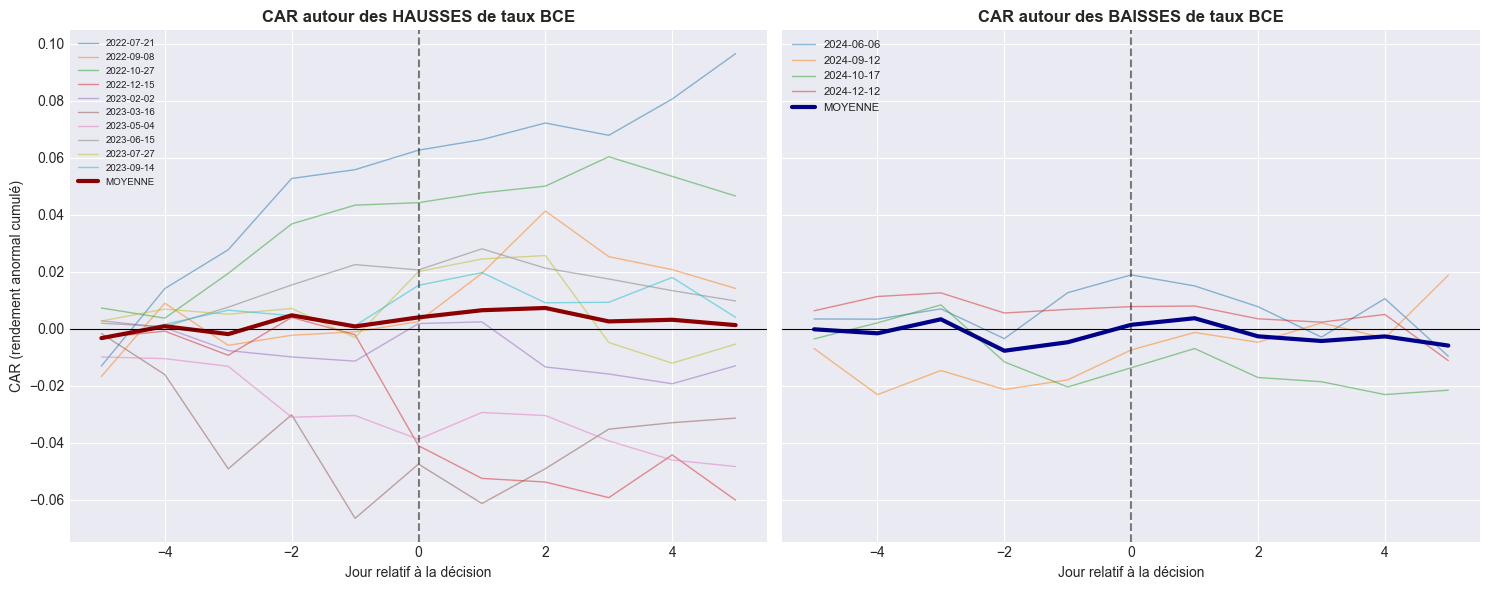

In [6]:
# Visualisation : trajectoires de CAR pour les hausses et les baisses
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- Graphique 1 : les HAUSSES ---
for event_date, car_traj in all_cars.items():
    change = bce_events.loc[event_date, "Change_bp"]
    if change > 0:
        axes[0].plot(car_traj.index, car_traj.values, alpha=0.5, linewidth=1,
                     label=event_date.date())

# Moyenne des hausses
hausses_dates = bce_events[bce_events["Change_bp"] > 0].index
car_moyen_hausse = pd.concat([all_cars[d] for d in hausses_dates], axis=1).mean(axis=1)
axes[0].plot(car_moyen_hausse.index, car_moyen_hausse.values, 
             color="darkred", linewidth=3, label="MOYENNE")

axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("CAR autour des HAUSSES de taux BCE", fontweight="bold")
axes[0].set_xlabel("Jour relatif à la décision")
axes[0].set_ylabel("CAR (rendement anormal cumulé)")
axes[0].legend(fontsize=7, loc="upper left")

# --- Graphique 2 : les BAISSES ---
for event_date, car_traj in all_cars.items():
    change = bce_events.loc[event_date, "Change_bp"]
    if change < 0:
        axes[1].plot(car_traj.index, car_traj.values, alpha=0.5, linewidth=1,
                     label=event_date.date())

# Moyenne des baisses
baisses_dates = bce_events[bce_events["Change_bp"] < 0].index
car_moyen_baisse = pd.concat([all_cars[d] for d in baisses_dates], axis=1).mean(axis=1)
axes[1].plot(car_moyen_baisse.index, car_moyen_baisse.values,
             color="darkblue", linewidth=3, label="MOYENNE")

axes[1].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("CAR autour des BAISSES de taux BCE", fontweight="bold")
axes[1].set_xlabel("Jour relatif à la décision")
axes[1].legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES / "03_car_hausses_baisses.png", dpi=150, bbox_inches="tight")
plt.show()

### Lecture des trajectoires de CAR

Les deux graphiques représentent l'évolution du rendement anormal cumulé (CAR) 
de l'EURO STOXX 50 dans la fenêtre [-5, +5] jours autour des décisions BCE, 
en distinguant les hausses (à gauche) et les baisses (à droite). La courbe 
épaisse représente la trajectoire moyenne.

**Un effet moyen faible et noyé dans le bruit**  
Pour les hausses comme pour les baisses, la trajectoire moyenne reste proche 
de zéro sur l'ensemble de la fenêtre. La moyenne des hausses atteint au maximum 
+0.7 % (jour +2) avant de refluer ; celle des baisses évolue légèrement en 
territoire négatif (environ −0.5 % au jour +5). Surtout, **aucune rupture nette 
n'apparaît au jour 0** : le moment de l'annonce ne produit pas de décrochage 
visible de la trajectoire moyenne.

**Une forte dispersion des réactions individuelles**  
Le graphique des hausses met en évidence une dispersion considérable des 
trajectoires individuelles : certaines décisions sont associées à un CAR de 
+10 %, d'autres à −6 %. Ces effets de signe opposé se compensent dans la moyenne, 
ce qui explique son aplatissement. La dispersion est plus contenue pour les 
baisses, mais l'échantillon y est aussi plus restreint (4 décisions, toutes 
de −25 bp).

**Interprétation : l'efficience des marchés et le rôle des anticipations**  
Ce résultat — l'absence d'effet moyen significatif des décisions BCE sur les 
actions — est cohérent avec l'hypothèse d'efficience des marchés. Les décisions 
de politique monétaire de la BCE sont en grande partie **anticipées** par les 
marchés : communications préalables, forward guidance, consensus des analystes. 
Lorsqu'une décision est pleinement anticipée, elle ne constitue pas une 
"surprise" et ne génère donc pas de réaction le jour de l'annonce, l'information 
ayant déjà été intégrée dans les prix.

Ce constat empirique souligne une limite de l'approche fondée sur les décisions 
brutes et justifie l'intérêt d'une analyse fondée sur les **surprises monétaires** 
(écart entre la décision et l'anticipation de marché) — piste identifiée comme 
extension possible du projet.

**Prochaines étapes**  
L'absence de réaction des actions ne signifie pas absence de transmission. 
Deux directions sont explorées dans la suite :
1. Tester si d'autres variables — spreads souverains, volatilité implicite — 
   réagissent davantage que les actions
2. Confirmer statistiquement l'absence d'effet par des tests de significativité 
   sur les CAR

In [7]:
# Event study sur le spread italien (delta_spread_IT)

results_spread_it = []
all_cars_spread_it = {}

for event_date, row in bce_events.iterrows():
    ar_df = compute_abnormal_returns(df, event_date, col="delta_spread_IT")
    
    if ar_df is None:
        continue
    
    car_final = ar_df["CAR"].iloc[-1]
    
    results_spread_it.append({
        "date": event_date,
        "change_bp": row["Change_bp"],
        "type": "Hausse" if row["Change_bp"] > 0 else ("Baisse" if row["Change_bp"] < 0 else "Hold"),
        "CAR_final": car_final,
    })
    
    all_cars_spread_it[event_date] = ar_df.set_index("rel_day")["CAR"]

results_spread_it_df = pd.DataFrame(results_spread_it).set_index("date")

print("Event study — Spread italien (variation cumulée anormale, en points de base)\n")
print(results_spread_it_df.to_string())

print(f"\n--- CAR moyen du spread IT par type de décision ---")
print(results_spread_it_df.groupby("type")["CAR_final"].agg(["mean", "std", "count"]).round(2))

Event study — Spread italien (variation cumulée anormale, en points de base)

            change_bp    type  CAR_final
date                                    
2019-09-12          0    Hold  14.386578
2020-03-12          0    Hold  19.277209
2020-06-04          0    Hold   3.912122
2021-12-16          0    Hold  -7.190184
2022-07-21         50  Hausse  42.069806
2022-09-08         75  Hausse  -4.633558
2022-10-27         75  Hausse -31.040059
2022-12-15         50  Hausse  40.245319
2023-02-02         50  Hausse  -3.970385
2023-03-16         50  Hausse  12.987168
2023-05-04         25  Hausse   9.124664
2023-06-15         25  Hausse -24.258883
2023-07-27         25  Hausse  -9.658541
2023-09-14         25  Hausse  -5.311437
2024-06-06        -25  Baisse   7.895209
2024-09-12        -25  Baisse   2.629385
2024-10-17        -25  Baisse  -6.386269
2024-12-12        -25  Baisse   5.816316

--- CAR moyen du spread IT par type de décision ---
        mean    std  count
type                  

### Lecture de l'event study sur le spread italien

L'analyse est reproduite sur la variation du spread souverain italien (`delta_spread_IT`), exprimée en points de base. L'hypothèse testée : un resserrement monétaire de la BCE pèserait davantage sur les pays les plus endettés, écartant ainsi le spread italien vis-à-vis de la courbe AAA.

**Un effet moyen non significatif**  
Le CAR moyen du spread italien autour des hausses de taux est de +2.56 bp, une valeur économiquement négligeable. L'écart-type associé est très élevé (24.2 bp), traduisant une forte hétérogénéité des réactions.

**Des réactions individuelles de signes opposés**  
La dispersion s'explique par des décisions aux effets contradictoires : certaines hausses s'accompagnent d'un écartement marqué du spread (+42 bp le 21/07/2022, +40 bp le 15/12/2022), d'autres d'un resserrement d'ampleur comparable (−31 bp le 27/10/2022, −24 bp le 15/06/2023). Ces effets se compensent dans la moyenne.

**Le cas des "Holds"**  
Les décisions sans changement de taux affichent le CAR moyen le plus élevé (+7.60 bp), tiré par le 12 mars 2020 (+19 bp). Contrairement au cas des actions, ce mouvement reflète un phénomène économique réel : durant le krach Covid, les spreads souverains se sont fortement écartés sous l'effet d'une fuite vers la qualité (vers la dette allemande). Ce mouvement reste toutefois étranger à la politique monétaire au sens strict.

**Conclusion**  
L'hypothèse d'un écartement systématique du spread italien autour des hausses de taux n'est pas validée sur la fenêtre [-5, +5]. Ce résultat rejoint celui obtenu sur les actions : les décisions BCE prises brutes ne génèrent pas de réaction de marché homogène.

In [8]:
# Event study sur la volatilité (delta_vstoxx)

results_vstoxx = []
all_cars_vstoxx = {}

for event_date, row in bce_events.iterrows():
    ar_df = compute_abnormal_returns(df, event_date, col="delta_vstoxx")
    
    if ar_df is None:
        continue
    
    car_final = ar_df["CAR"].iloc[-1]
    
    results_vstoxx.append({
        "date": event_date,
        "change_bp": row["Change_bp"],
        "type": "Hausse" if row["Change_bp"] > 0 else ("Baisse" if row["Change_bp"] < 0 else "Hold"),
        "CAR_final": car_final,
    })
    
    all_cars_vstoxx[event_date] = ar_df.set_index("rel_day")["CAR"]

results_vstoxx_df = pd.DataFrame(results_vstoxx).set_index("date")

print("Event study — VSTOXX (variation cumulée anormale, en points)\n")
print(results_vstoxx_df.to_string())

print(f"\n--- CAR moyen du VSTOXX par type de décision ---")
print(results_vstoxx_df.groupby("type")["CAR_final"].agg(["mean", "std", "count"]).round(2))

Event study — VSTOXX (variation cumulée anormale, en points)

            change_bp    type  CAR_final
date                                    
2019-09-12          0    Hold    -3.0084
2020-03-12          0    Hold    41.8404
2020-06-04          0    Hold    13.7704
2021-12-16          0    Hold    -9.2956
2022-07-21         50  Hausse   -10.2568
2022-09-08         75  Hausse    -3.6472
2022-10-27         75  Hausse    -5.4364
2022-12-15         50  Hausse    -0.8952
2023-02-02         50  Hausse     0.7092
2023-03-16         50  Hausse     3.7916
2023-05-04         25  Hausse     5.9584
2023-06-15         25  Hausse     0.4540
2023-07-27         25  Hausse     1.6144
2023-09-14         25  Hausse     1.6004
2024-06-06        -25  Baisse     4.4784
2024-09-12        -25  Baisse    -5.9196
2024-10-17        -25  Baisse     0.0200
2024-12-12        -25  Baisse     4.5896

--- CAR moyen du VSTOXX par type de décision ---
         mean    std  count
type                       
Baisse   0.7

### Lecture de l'event study sur la volatilité (VSTOXX)

La même méthodologie est appliquée à la variation du VSTOXX (`delta_vstoxx`), 
exprimée en points. L'hypothèse testée : les décisions BCE pourraient générer 
de l'incertitude — donc une hausse de la volatilité implicite — même sans 
provoquer de mouvement directionnel des prix.

**Un effet moyen non significatif**  
Le CAR moyen du VSTOXX est de −0.61 point autour des hausses de taux et de 
+0.79 point autour des baisses. Ces valeurs sont proches de zéro et les 
écarts-types (environ 4.7 à 4.9 points) indiquent là encore une forte 
dispersion des réactions individuelles.

**Le cas des "Holds"**  
Comme pour le spread italien, le CAR moyen des "holds" (+10.83 points) est 
presque entièrement dû au 12 mars 2020 (+41.8 points), date du pic de 
volatilité lié au Covid-19. Hors cet épisode, les décisions sans changement 
de taux ne présentent pas de réaction particulière de la volatilité.

**Conclusion**  
Les décisions BCE ne s'accompagnent pas d'une hausse systématique de la 
volatilité implicite sur la fenêtre étudiée. La transmission ne passe donc 
pas non plus par un canal de "nervosité" mesurable à cet horizon.

In [15]:
# Tests de significativité statistique sur les CAR
from scipy import stats

def test_car(car_series, label):
    """
    Effectue un test t à un échantillon contre H0 : moyenne = 0
    Retourne : moyenne, écart-type, t-stat, p-value, significatif (oui/non)
    """
    mean = car_series.mean()
    std = car_series.std()
    n = len(car_series)
    t_stat, p_value = stats.ttest_1samp(car_series, popmean=0)
    significant = "✓ Oui" if p_value < 0.05 else " X Non"
    
    return {
        "Variable": label,
        "N": n,
        "Moyenne": round(mean, 4),
        "Écart-type": round(std, 4),
        "t-stat": round(t_stat, 3),
        "p-value": round(p_value, 4),
        "Significatif (5%)": significant,
    }

# Construction du tableau de résultats
tests = []

# --- Sur les HAUSSES (10 décisions) ---
hausses_idx = bce_events[bce_events["Change_bp"] > 0].index

tests.append(test_car(
    results_df.loc[hausses_idx, "CAR_final"],
    "Hausses — STOXX 50 (rendement)"
))
tests.append(test_car(
    results_spread_it_df.loc[hausses_idx, "CAR_final"],
    "Hausses — Spread italien (bp)"
))
tests.append(test_car(
    results_vstoxx_df.loc[hausses_idx, "CAR_final"],
    "Hausses — VSTOXX (points)"
))

# --- Sur les BAISSES (4 décisions) ---
baisses_idx = bce_events[bce_events["Change_bp"] < 0].index

tests.append(test_car(
    results_df.loc[baisses_idx, "CAR_final"],
    "Baisses — STOXX 50 (rendement)"
))
tests.append(test_car(
    results_spread_it_df.loc[baisses_idx, "CAR_final"],
    "Baisses — Spread italien (bp)"
))
tests.append(test_car(
    results_vstoxx_df.loc[baisses_idx, "CAR_final"],
    "Baisses — VSTOXX (points)"
))

# Affichage
tests_df = pd.DataFrame(tests)
print("=" * 90)
print("TESTS DE SIGNIFICATIVITÉ — H0 : CAR moyen = 0 (pas d'effet)")
print("=" * 90)
print(tests_df.to_string(index=False))

# Sauvegarde du tableau pour le README
tests_df.to_csv(TABLES / "03_tests_significativite.csv", index=False)
print(f"\n Tableau sauvegardé dans {TABLES / '03_tests_significativite.csv'}")

TESTS DE SIGNIFICATIVITÉ — H0 : CAR moyen = 0 (pas d'effet)
                      Variable  N  Moyenne  Écart-type  t-stat  p-value Significatif (5%)
Hausses — STOXX 50 (rendement) 10   0.0013      0.0458   0.090   0.9305             X Non
 Hausses — Spread italien (bp) 10   2.5554     24.2370   0.333   0.7465             X Non
     Hausses — VSTOXX (points) 10  -0.6108      4.7245  -0.409   0.6922             X Non
Baisses — STOXX 50 (rendement)  4  -0.0059      0.0173  -0.680   0.5451             X Non
 Baisses — Spread italien (bp)  4   2.4887      6.3005   0.790   0.4872             X Non
     Baisses — VSTOXX (points)  4   0.7921      4.9549   0.320   0.7701             X Non

 Tableau sauvegardé dans C:\Users\volka\Documents\ecb-monetary-policy-transmission\output\tables\03_tests_significativite.csv


### Interprétation des tests de significativité

Les tests t à un échantillon confirment statistiquement les observations visuelles 
et descriptives : **aucun CAR moyen n'est significativement différent de zéro au 
seuil de 5 %**, sur aucune des trois variables (EURO STOXX 50, spread italien, 
VSTOXX), ni pour les hausses (N = 10), ni pour les baisses (N = 4).

**Lecture des p-values**  
Toutes les p-values sont nettement supérieures à 0.05, plusieurs dépassent même 0.7. 
Ces valeurs élevées signifient qu'il n'y a aucune raison statistique de rejeter 
l'hypothèse nulle "pas d'effet". Les t-statistiques sont toutes inférieures à 1 
en valeur absolue, confirmant que les moyennes observées sont au mieux à moins 
d'un écart-type de zéro.

**Limites de puissance statistique — mais résultat tout de même substantiel**  
Avec seulement 10 hausses et 4 baisses, la puissance du test est limitée : 
un effet véritable mais faible pourrait passer inaperçu. Cette limite est réelle 
et doit être mentionnée. Cependant, deux éléments suggèrent que le résultat n'est 
pas qu'un artefact d'échantillon :

1. Les moyennes observées sont **substantiellement faibles** en valeur économique 
   (0.13 % de CAR moyen sur le STOXX 50, 2.5 bp sur le spread italien)
2. Les écarts-types sont **très élevés relativement aux moyennes** : même avec 
   un échantillon plus large, il faudrait que l'effet réel soit très important 
   pour devenir détectable

**Conclusion empirique de l'event study**  
Les décisions de politique monétaire de la BCE entre 2019 et 2024, prises comme 
des événements bruts sur la fenêtre [-5, +5], ne génèrent pas de réaction de 
marché significative — ni en moyenne, ni de façon statistiquement détectable. 
Ce résultat est cohérent à travers les trois variables testées (actions, spreads, 
volatilité) et avec l'hypothèse d'efficience des marchés : une décision 
largement anticipée par les analystes et intégrée aux prix avant son annonce 
ne peut pas, par construction, générer de réaction le jour de l'annonce.

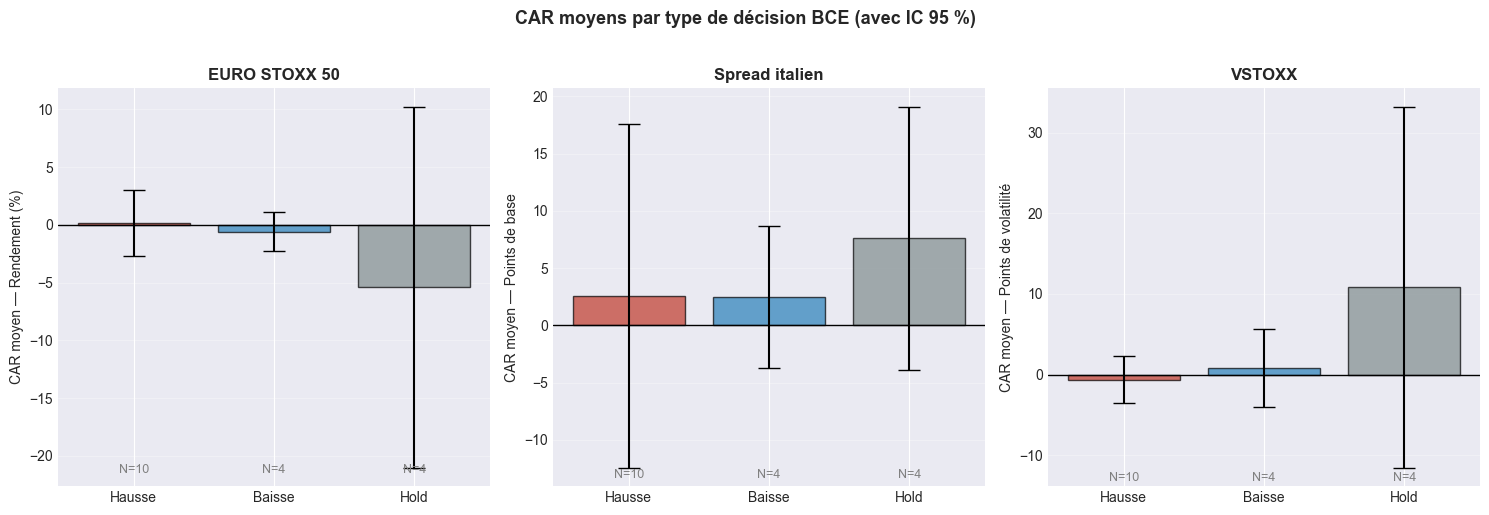

Graphique sauvegardé dans output/figures/03_car_recap.png


In [16]:
# Graphique récapitulatif : CAR moyens et intervalles de confiance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Liste des datasets à représenter
datasets = [
    (results_df, "EURO STOXX 50", "Rendement (%)", 100, axes[0]),
    (results_spread_it_df, "Spread italien", "Points de base", 1, axes[1]),
    (results_vstoxx_df, "VSTOXX", "Points de volatilité", 1, axes[2]),
]

for results_data, titre, ylabel, multiplier, ax in datasets:
    # Calculer moyennes et intervalles de confiance à 95% par type
    groupes = ["Hausse", "Baisse", "Hold"]
    moyennes = []
    erreurs = []
    
    for g in groupes:
        sub = results_data[results_data["type"] == g]["CAR_final"] * multiplier
        moyennes.append(sub.mean())
        # Intervalle de confiance à 95% : 1.96 * écart-type / sqrt(n)
        erreurs.append(1.96 * sub.std() / np.sqrt(len(sub)))
    
    # Barplot
    couleurs = ["#c0392b", "#2980b9", "#7f8c8d"]
    bars = ax.bar(groupes, moyennes, yerr=erreurs, capsize=8,
                  color=couleurs, alpha=0.7, edgecolor="black", linewidth=1)
    
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(titre, fontweight="bold", fontsize=12)
    ax.set_ylabel(f"CAR moyen — {ylabel}")
    ax.grid(True, alpha=0.3, axis="y")
    
    # Ajouter le N sous chaque barre
    for i, g in enumerate(groupes):
        n = (results_data["type"] == g).sum()
        ax.text(i, ax.get_ylim()[0] * 0.95, f"N={n}", ha="center", fontsize=9, color="gray")

plt.suptitle("CAR moyens par type de décision BCE (avec IC 95 %)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "03_car_recap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé dans output/figures/03_car_recap.png")

### Lecture du graphique récapitulatif

Ce graphique synthétise visuellement les résultats des trois event studies. 
Pour chaque variable et chaque type de décision, la barre représente le CAR 
moyen et les "moustaches" l'intervalle de confiance à 95 %.

**La lecture visuelle est sans appel** : sur les trois variables et pour tous 
les types de décision, les intervalles de confiance **traversent systématiquement 
la ligne du zéro**. C'est la signature visuelle d'un résultat non significatif : 
on ne peut pas exclure que le véritable CAR moyen soit nul.

Cette représentation confirme d'un seul regard la conclusion des tests t : 
**aucune des trois variables ne réagit de façon statistiquement détectable 
aux décisions BCE prises brutes**.

## Conclusion de l'event study

Ce notebook a appliqué une méthodologie classique d'event study aux 18 décisions de politique monétaire de la BCE sur la période 2019-2024. La méthode a été déclinée sur trois variables couvrant trois canaux distincts de transmission :

- **Marché actions** — EURO STOXX 50 (rendements logarithmiques)
- **Marché obligataire souverain** — spread italien vs courbe AAA zone euro
- **Volatilité implicite** — VSTOXX (variation quotidienne)

### Résultat principal

**Aucune des trois variables ne présente de réaction moyenne statistiquement significative aux décisions BCE sur la fenêtre [-5, +5] jours.** Ce résultat est confirmé par :

1. L'aplatissement des trajectoires moyennes de CAR autour du jour d'annonce
2. La très forte dispersion des réactions individuelles, qui se compensent dans la moyenne
3. Des tests t à un échantillon dont toutes les p-values dépassent 0.05 (la plupart au-dessus de 0.5)

### Interprétation économique

Ce résultat n'est pas un échec — c'est une illustration empirique de **l'hypothèse d'efficience semi-forte des marchés**. Les décisions BCE sont en grande partie anticipées par les analystes et les marchés via les communications préalables (forward guidance, discours de Christine Lagarde, projections macroéconomiques publiées). Lorsqu'une décision est pleinement anticipée, elle est déjà intégrée dans les prix avant son annonce — et l'annonce elle-même ne génère donc pas de choc directionnel.

### Limites de l'analyse

Trois limites doivent être mentionnées :

**1. Puissance statistique limitée**  
Avec 10 hausses et 4 baisses, la capacité du test t à détecter un effet faible mais réel. Cependant, les écarts-types très élevés relativement aux moyennes suggèrent que l'effet, s'il existe, est de toute façon faible en valeur économique.

**2. Pollution par des chocs exogènes**  
Le 12 mars 2020 illustre la principale limite de la méthode : l'event study ne peut pas distinguer la réaction à l'événement étudié des autres chocs concomitants. Ce jour-là, ce n'est pas la BCE qui a fait bouger les marchés, 
mais le Covid-19.

**3. Décisions brutes vs surprises monétaires**  
La limite la plus fondamentale est conceptuelle : nous avons étudié la réaction aux **décisions** elles-mêmes, alors que la théorie financière suggère que ce sont les **surprises**, c'est-à-dire l'écart entre la décision et l'anticipation de marché qui devraient générer les réactions. L'intégration des OIS comme mesure des anticipations constitue l'extension naturelle de ce travail.

### Apport méthodologique

Au-delà du résultat empirique, ce notebook met en œuvre une méthodologie rigoureuse et reproductible : construction de fenêtres d'estimation et d'événement, calcul des rendements anormaux et de leur cumul, agrégation 
par type de décision, tests de significativité. Cette infrastructure est réutilisable pour d'éventuelles extensions (surprises monétaires, autres variables, autres fenêtres d'événement).